# Digital Learning Anaiytics and Prediction System

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings("ignore")


Data Inspection

In [2]:
#load the dataset
df = pd.read_csv('Data/digital_learning_analytics.csv')

In [3]:
df.head()

,learner_id,age,gender,education_level,country,employment_status,prior_online_courses,digital_literacy_score,app_category,daily_app_minutes,...,content_recommendations_followed,knowledge_gaps_identified,remediation_modules_completed,time_to_mastery_hours,mastery_score,learning_efficiency_score,enrollment_date,last_activity_date,total_learning_hours,engagement_consistency
0,LRN00000001,28,Non-binary,Graduate,Australia,Student,0,8.04,Test Prep,85.0,...,47.5,2,0,21.0,44.2,21.05,2022-07-03,2022-07-16,34.2,0.527
1,LRN00000002,33,Male,Graduate,United States,Retired,7,7.07,Mathematics,54.2,...,35.9,10,2,22.4,13.0,5.80,2024-09-24,2024-10-17,34.9,0.441
2,LRN00000003,20,Male,Professional Certificate,India,Employed Full-time,6,7.79,Language Learning,53.4,...,40.6,4,0,70.5,43.2,6.13,2022-03-25,2022-04-04,37.8,0.494
3,LRN00000004,27,Female,Doctoral,South Africa,Self-employed,5,7.24,Test Prep,60.3,...,42.5,0,0,39.1,44.6,11.41,2025-01-13,2025-02-04,41.7,0.493
4,LRN00000005,50,Male,Some College,Germany,Unemployed,5,4.77,Soft Skills,31.8,...,47.4,2,0,52.6,35.1,6.67,2024-09-27,2024-11-01,36.9,0.305


In [4]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 43 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   learner_id                        100000 non-null  object 
 1   age                               100000 non-null  int64  
 2   gender                            100000 non-null  object 
 3   education_level                   100000 non-null  object 
 4   country                           100000 non-null  object 
 5   employment_status                 100000 non-null  object 
 6   prior_online_courses              100000 non-null  int64  
 7   digital_literacy_score            100000 non-null  float64
 8   app_category                      100000 non-null  object 
 9   daily_app_minutes                 100000 non-null  float64
 10  session_count_weekly              100000 non-null  int64  
 11  app_completion_rate               100000 non-null  fl

(100000, 43)

In [5]:
df.tail()

,learner_id,age,gender,education_level,country,employment_status,prior_online_courses,digital_literacy_score,app_category,daily_app_minutes,...,content_recommendations_followed,knowledge_gaps_identified,remediation_modules_completed,time_to_mastery_hours,mastery_score,learning_efficiency_score,enrollment_date,last_activity_date,total_learning_hours,engagement_consistency
99995,LRN00099996,45,Female,High School,India,Employed Full-time,0,7.19,Science & Engineering,36.3,...,70.9,6,2,27.9,65.9,23.62,2022-12-23,2023-03-29,22.2,0.737
99996,LRN00099997,53,Female,Professional Certificate,India,Unemployed,5,4.80,Science & Engineering,18.0,...,79.5,6,1,46.8,48.9,10.45,2021-03-22,2021-04-29,28.3,0.436
99997,LRN00099998,39,Male,Undergraduate,South Africa,Employed Part-time,1,5.18,Science & Engineering,46.2,...,70.8,1,0,42.7,48.0,11.24,2025-09-18,2025-12-23,74.2,0.656
99998,LRN00099999,60,Male,Undergraduate,United States,Unemployed,3,5.56,Soft Skills,23.0,...,61.3,5,2,24.0,51.7,21.54,2025-09-12,2025-12-09,21.6,0.398
99999,LRN00100000,48,Male,Some College,Mexico,Self-employed,0,5.24,Science & Engineering,25.3,...,83.2,4,0,33.1,42.1,12.72,2023-12-03,2024-02-29,21.9,0.456


In [6]:

#summary statistics of the dataset
df.describe(include = 'all')

,learner_id,age,gender,education_level,country,employment_status,prior_online_courses,digital_literacy_score,app_category,daily_app_minutes,...,content_recommendations_followed,knowledge_gaps_identified,remediation_modules_completed,time_to_mastery_hours,mastery_score,learning_efficiency_score,enrollment_date,last_activity_date,total_learning_hours,engagement_consistency
count,100000,100000.000000,100000,100000,100000,100000,100000.000000,100000.000000,100000,100000.000000,...,98486.000000,100000.000000,100000.00000,100000.000000,100000.000000,99027.000000,100000,100000,100000.000000,100000.000000
unique,100000,NaN,4,6,51,6,NaN,NaN,6,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2192,2227,NaN,NaN
top,LRN00099984,NaN,Male,Undergraduate,United States,Employed Full-time,NaN,NaN,Mathematics,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2021-03-17,2026-02-06,NaN,NaN
freq,1,NaN,48165,34772,24344,34840,NaN,NaN,16820,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,69,521,NaN,NaN
mean,NaN,34.460960,NaN,NaN,NaN,NaN,4.503200,6.273997,NaN,45.403519,...,56.067161,4.002640,0.86042,36.909821,47.790251,14.939446,NaN,NaN,44.954331,0.490421
std,NaN,12.834553,NaN,NaN,NaN,NaN,4.974038,1.343865,NaN,22.550577,...,18.472460,1.997932,1.00690,12.020818,11.845493,8.115122,NaN,NaN,40.708444,0.199641
min,NaN,14.000000,NaN,NaN,NaN,NaN,0.000000,1.710000,NaN,5.000000,...,10.000000,0.000000,0.00000,10.000000,1.700000,0.420000,NaN,NaN,5.100000,0.000000
25%,NaN,24.000000,NaN,NaN,NaN,NaN,1.000000,5.310000,NaN,29.200000,...,42.600000,3.000000,0.00000,28.400000,39.600000,9.660000,NaN,NaN,22.700000,0.351000
50%,NaN,32.000000,NaN,NaN,NaN,NaN,3.000000,6.160000,NaN,42.300000,...,53.400000,4.000000,1.00000,36.400000,47.300000,12.940000,NaN,NaN,31.800000,0.453000
75%,NaN,44.000000,NaN,NaN,NaN,NaN,6.000000,7.130000,NaN,58.800000,...,67.700000,5.000000,1.00000,44.900000,55.500000,17.810000,NaN,NaN,51.200000,0.594000


In [7]:
#missing values 
df.isnull().sum()

learner_id                             0
age                                    0
gender                                 0
education_level                        0
country                                0
employment_status                      0
prior_online_courses                   0
digital_literacy_score                 0
app_category                           0
daily_app_minutes                      0
session_count_weekly                   0
app_completion_rate                    0
in_app_quiz_score                      0
gamification_engagement             2490
skill_pre_score                        0
skill_post_score                       0
essay_topic_category                   0
essay_word_count                       0
essay_grammar_errors                   0
essay_vocabulary_richness           1973
essay_coherence_score               2022
human_grader_score                     0
automated_score                        0
mooc_platform                          0
course_category 

In [8]:
#identifying garberge values 
for i in df.select_dtypes(include="object").columns:
           print(df[i].value_counts())
           print("***"*10)

learner_id
LRN00099984    1
LRN00099983    1
LRN00099982    1
LRN00099981    1
LRN00099980    1
              ..
LRN00000005    1
LRN00000004    1
LRN00000003    1
LRN00000002    1
LRN00000001    1
Name: count, Length: 100000, dtype: int64
******************************
gender
Male                 48165
Female               46824
Non-binary            2978
Prefer not to say     2033
Name: count, dtype: int64
******************************
education_level
Undergraduate               34772
Graduate                    25280
High School                 15105
Some College                11937
Professional Certificate     7938
Doctoral                     4968
Name: count, dtype: int64
******************************
country
United States           24344
India                   17362
United Kingdom           7824
Canada                   4703
Germany                  3824
Australia                2934
France                   2911
Brazil                   2813
Mexico                   2366
Ni

In [9]:
#checking duplicates
df.duplicated().sum()

np.int64(0)

In [10]:
# identifying date types
df.dtypes

learner_id                           object
age                                   int64
gender                               object
education_level                      object
country                              object
employment_status                    object
prior_online_courses                  int64
digital_literacy_score              float64
app_category                         object
daily_app_minutes                   float64
session_count_weekly                  int64
app_completion_rate                 float64
in_app_quiz_score                   float64
gamification_engagement             float64
skill_pre_score                     float64
skill_post_score                    float64
essay_topic_category                 object
essay_word_count                      int64
essay_grammar_errors                  int64
essay_vocabulary_richness           float64
essay_coherence_score               float64
human_grader_score                  float64
automated_score                 

Target Distribution(regression & classification)

In [11]:
#target Distribution (course_completed) 
# Class counts
class_counts = df['course_completed'].value_counts()

# Class percentages
class_percent = df['course_completed'].value_counts(normalize=True) * 100

completion_rate = class_percent[1]
non_completion_rate = class_percent[0]

print(f"Completed: {completion_rate:.2f}%")
print(f"Not Completed: {non_completion_rate:.2f}%")

Completed: 30.64%
Not Completed: 69.36%


In [12]:
# target distribution (mastery_score) 
min_score = df['mastery_score'].min()
max_score = df['mastery_score'].max()
mean_score = df['mastery_score'].mean()

print(f"Min: {min_score}")
print(f"Max: {max_score}")
print(f"Mean: {mean_score:.2f}")

Min: 1.7
Max: 100.0
Mean: 47.79


In [13]:
skewness = df['mastery_score'].skew()
print(f"Skewness: {skewness:.3f}")

Skewness: 0.215


 Exploratory Data Analysis (EDA) with Visualizations

In [14]:
df.describe(include='object')

,learner_id,gender,education_level,country,employment_status,app_category,essay_topic_category,mooc_platform,course_category,learning_path_type,enrollment_date,last_activity_date
count,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000
unique,100000,4,6,51,6,6,6,7,6,4,2192,2227
top,LRN00099984,Male,Undergraduate,United States,Employed Full-time,Mathematics,Descriptive,FutureLearn,Technology,Fully Adaptive,2021-03-17,2026-02-06
freq,1,48165,34772,24344,34840,16820,16755,14510,16786,25137,69,521


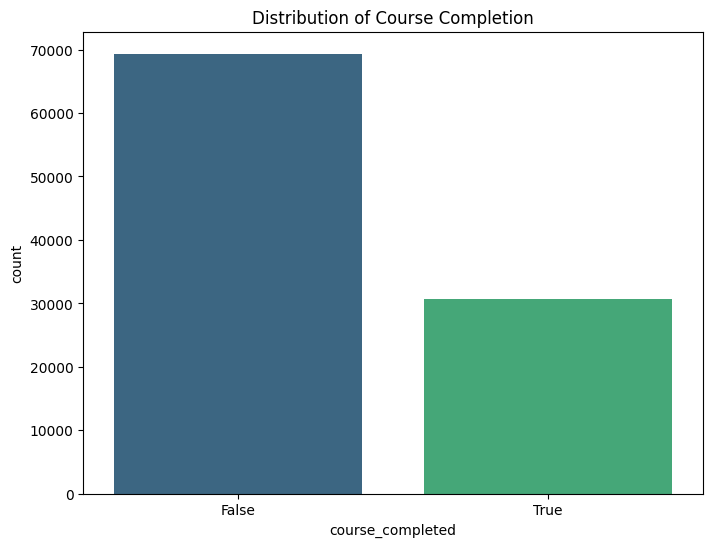

In [15]:
# 1. Distribution of Target Variable (course_completed)
plt.figure(figsize=(8, 6))
sns.countplot(x="course_completed", data=df, palette="viridis")
plt.title("Distribution of Course Completion")
plt.show()

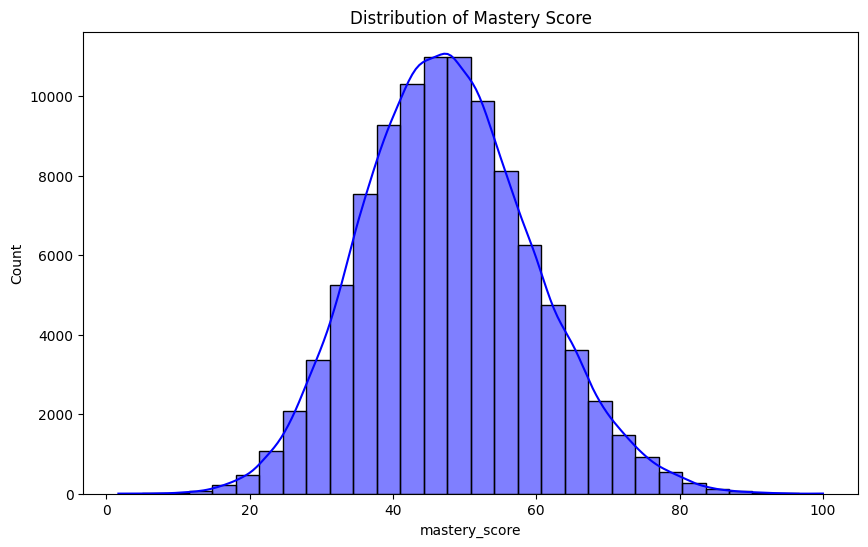

In [16]:
# 2. Mastery Score Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df["mastery_score"], bins=30, kde=True, color="blue")
plt.title("Distribution of Mastery Score")
plt.show()


Generating Box Plots for Outlier Detection...


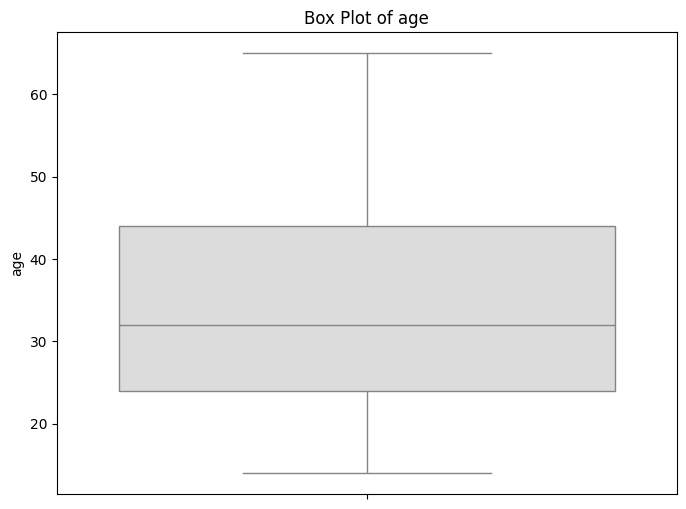

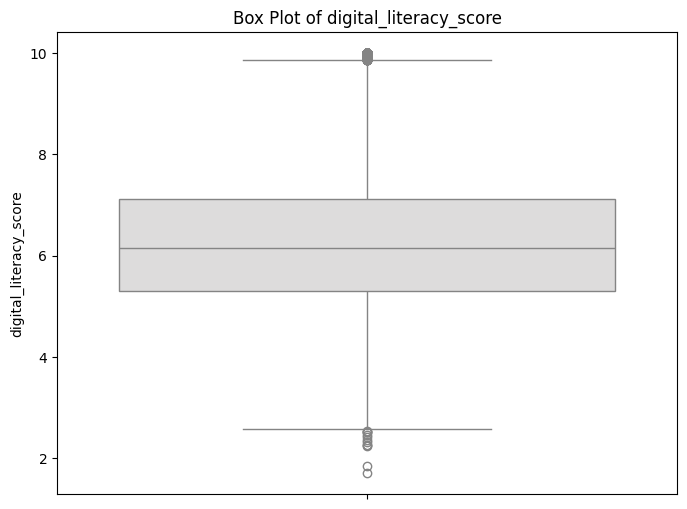

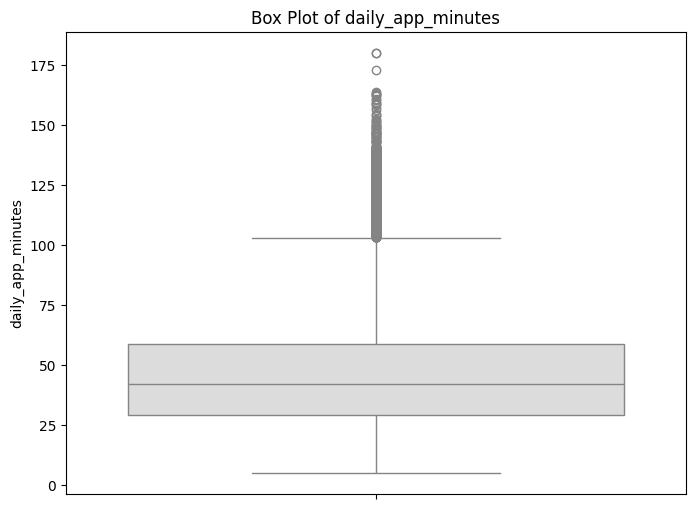

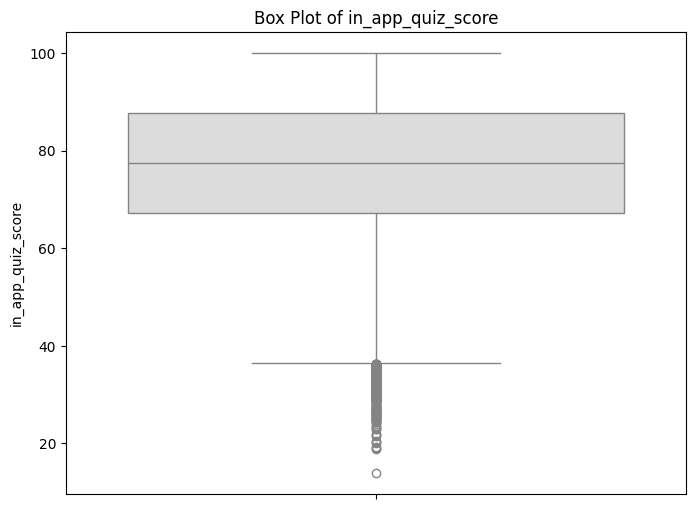

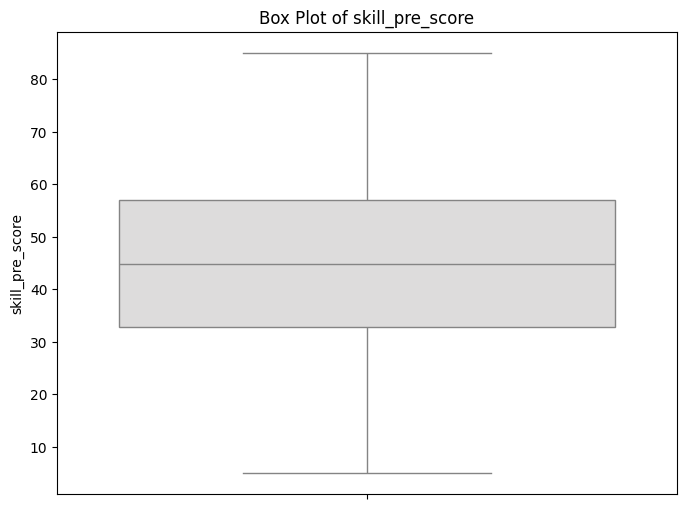

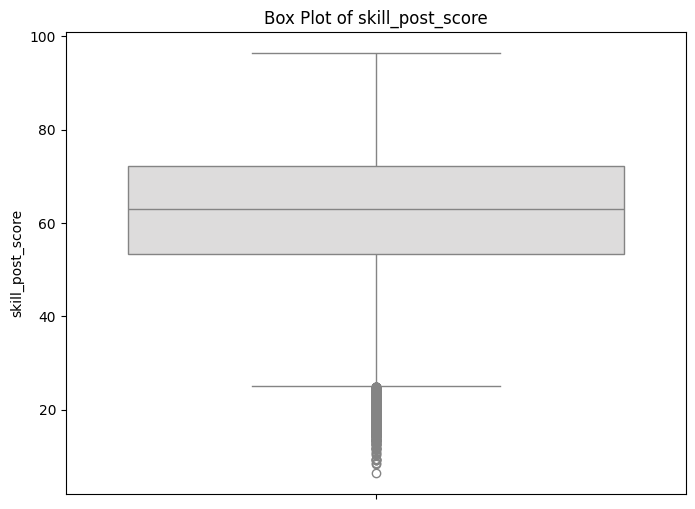

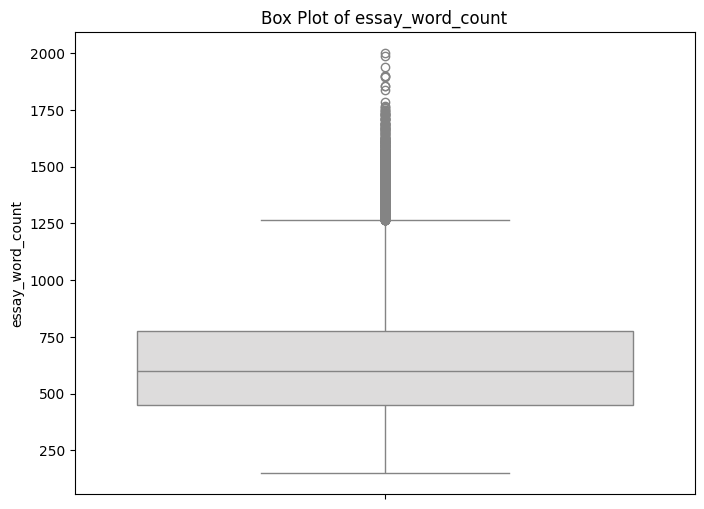

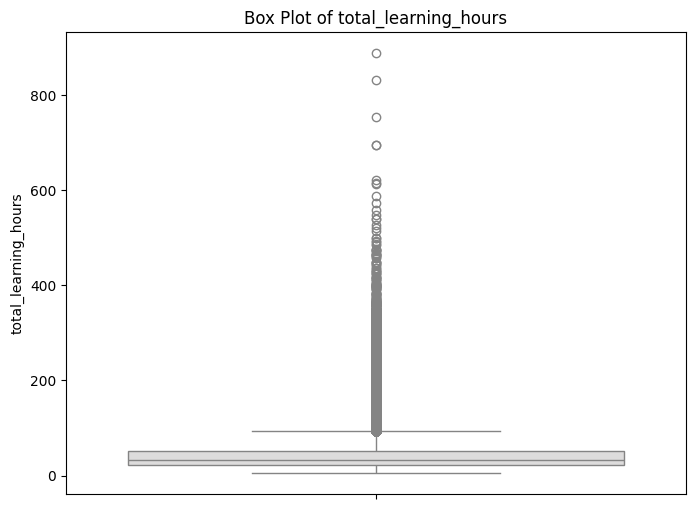

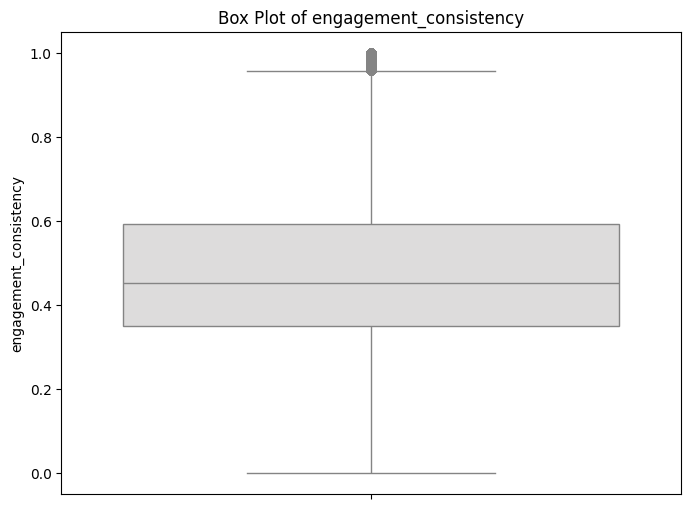

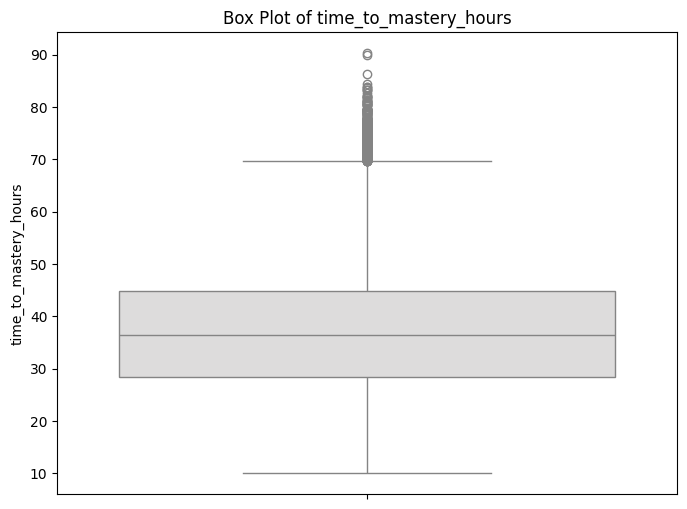

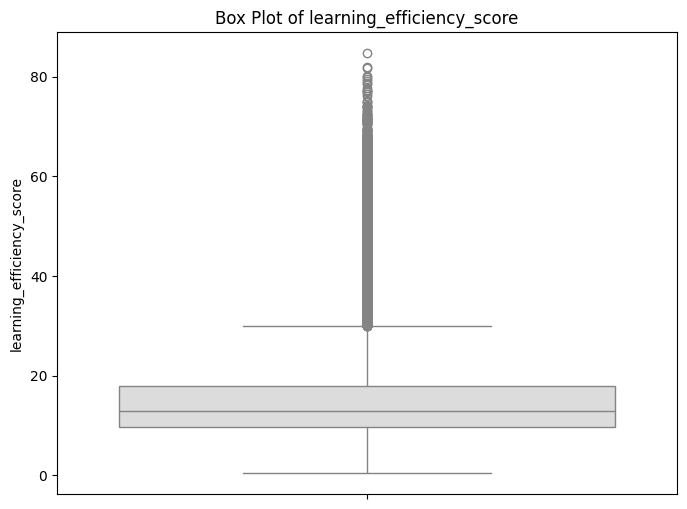

In [17]:
# 3. Box Plots for Outlier Detection (selected numerical features)
print("\nGenerating Box Plots for Outlier Detection...")
outlier_cols = [
    "age", "digital_literacy_score", "daily_app_minutes", "in_app_quiz_score",
    "skill_pre_score", "skill_post_score", "essay_word_count", "total_learning_hours",
    "engagement_consistency", "time_to_mastery_hours", "learning_efficiency_score"
]

for col in outlier_cols:
    plt.figure(figsize=(8, 6))
    sns.boxplot(y=df[col], palette="coolwarm")
    plt.title(f"Box Plot of {col}")
    plt.ylabel(col)
    plt.show()

In [18]:
df.columns

Index(['learner_id', 'age', 'gender', 'education_level', 'country',
       'employment_status', 'prior_online_courses', 'digital_literacy_score',
       'app_category', 'daily_app_minutes', 'session_count_weekly',
       'app_completion_rate', 'in_app_quiz_score', 'gamification_engagement',
       'skill_pre_score', 'skill_post_score', 'essay_topic_category',
       'essay_word_count', 'essay_grammar_errors', 'essay_vocabulary_richness',
       'essay_coherence_score', 'human_grader_score', 'automated_score',
       'mooc_platform', 'course_category', 'course_duration_weeks',
       'video_completion_pct', 'assignment_submission_rate', 'forum_posts',
       'peer_review_given', 'course_completed', 'learning_path_type',
       'content_difficulty_avg', 'content_recommendations_followed',
       'knowledge_gaps_identified', 'remediation_modules_completed',
       'time_to_mastery_hours', 'mastery_score', 'learning_efficiency_score',
       'enrollment_date', 'last_activity_date', 'total_

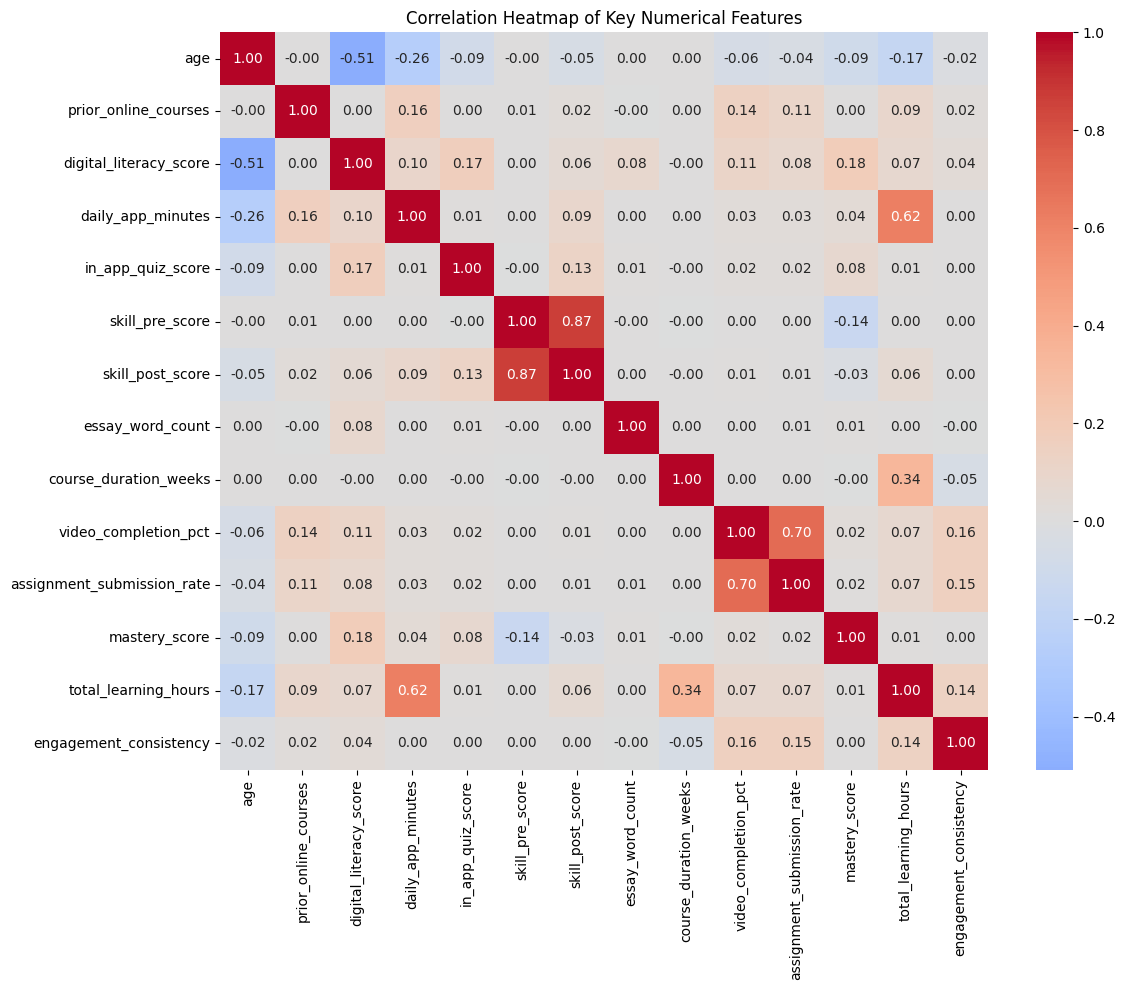

In [19]:
# 4. Correlation Heatmap (subset of numerical features)
numerical_cols = df.select_dtypes(include=[np.number]).columns
subset_cols = [
    "age", "prior_online_courses", "digital_literacy_score", "daily_app_minutes",
    "in_app_quiz_score", "skill_pre_score", "skill_post_score", "essay_word_count",
    "course_duration_weeks", "video_completion_pct", "assignment_submission_rate",
    "mastery_score", "total_learning_hours", "engagement_consistency"
]
plt.figure(figsize=(12, 10))
sns.heatmap(df[subset_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Key Numerical Features")
plt.tight_layout()
plt.show()

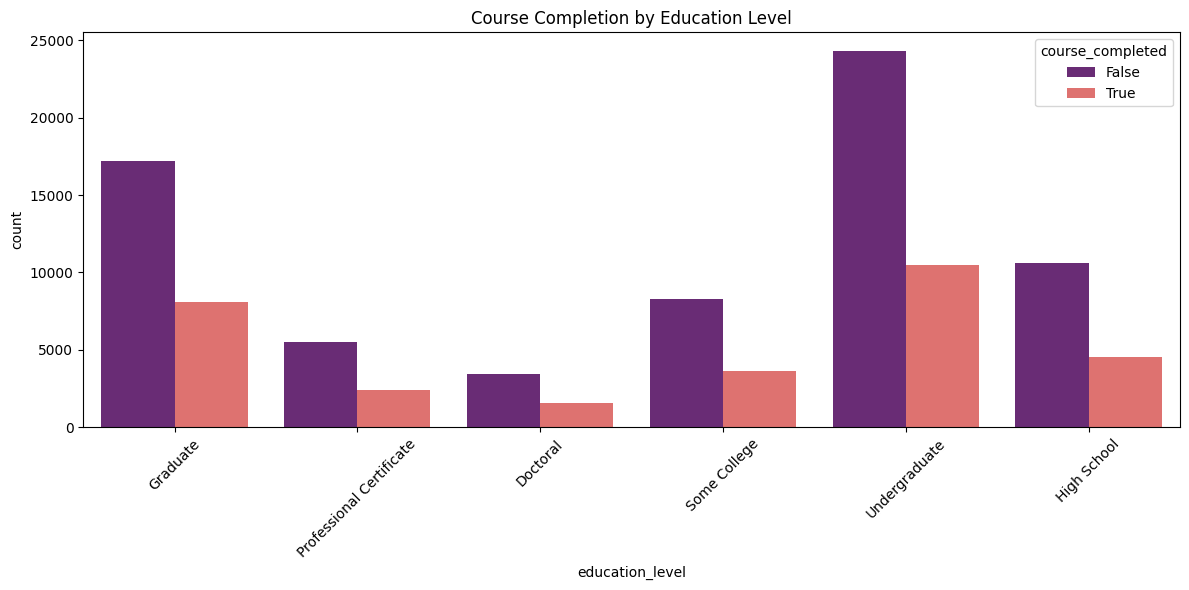

In [20]:
# 5. Course Completion by Education Level
plt.figure(figsize=(12, 6))
sns.countplot(x="education_level", hue="course_completed", data=df, palette="magma")
plt.title("Course Completion by Education Level")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Skill Improvement vs Course Completion')

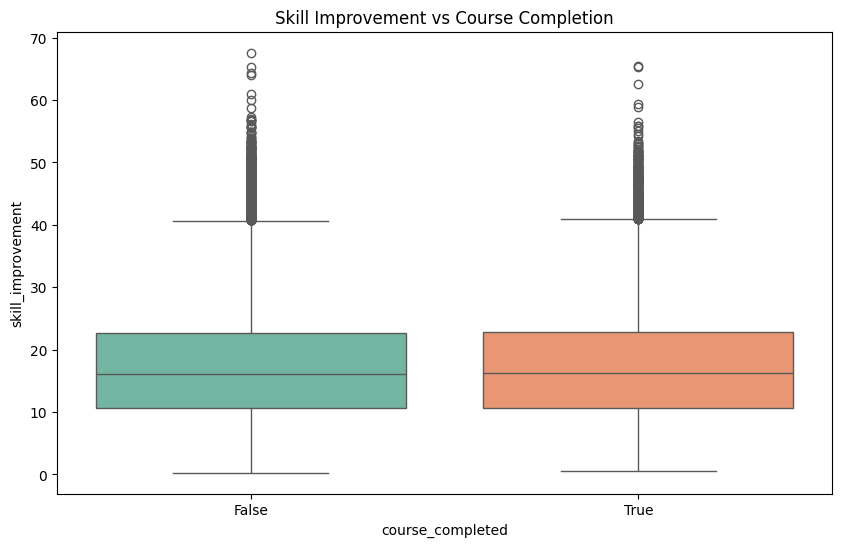

In [21]:
# 6. Skill Improvement (Post - Pre) vs Course Completion
df["skill_improvement"] = df["skill_post_score"] - df["skill_pre_score"]
plt.figure(figsize=(10, 6))
sns.boxplot(x="course_completed", y="skill_improvement", data=df, palette="Set2")
plt.title("Skill Improvement vs Course Completion")

advance eda

In [22]:
# Convert date columns to datetime objects
df["enrollment_date"] = pd.to_datetime(df["enrollment_date"])
df["last_activity_date"] = pd.to_datetime(df["last_activity_date"])

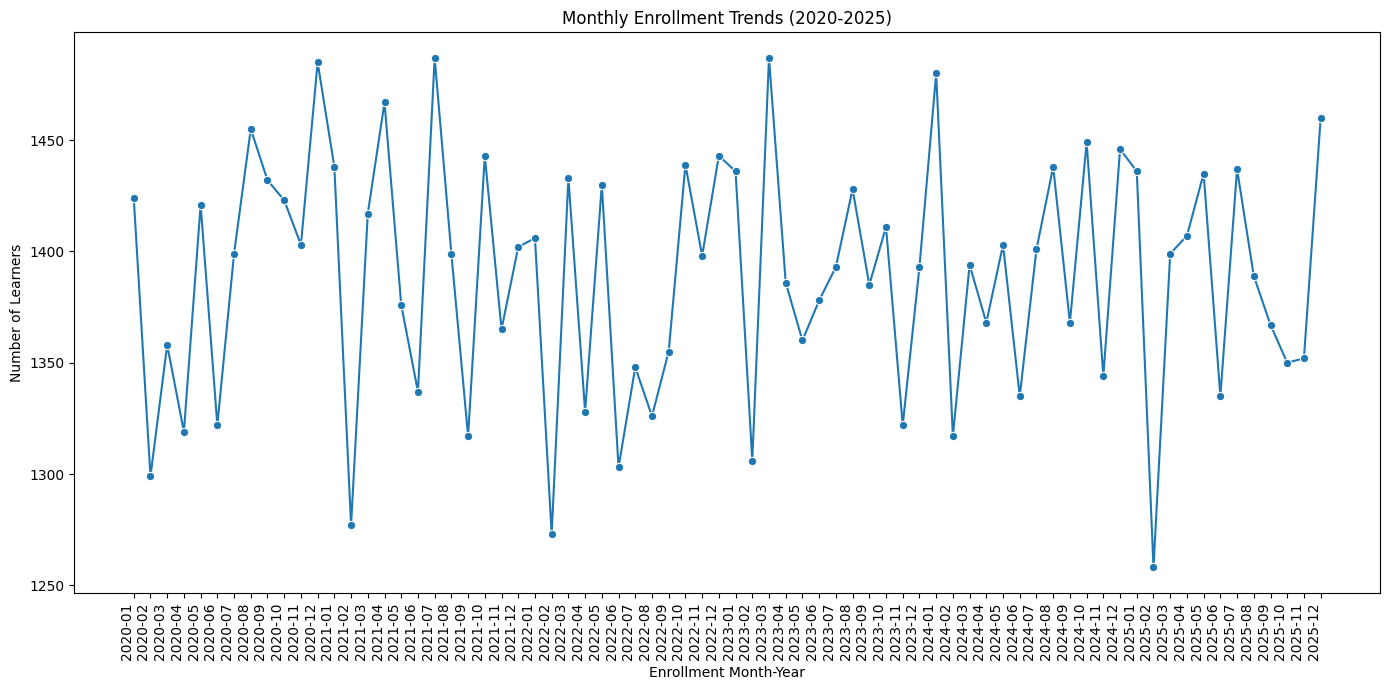

In [23]:
# 7. Time-series Analysis: Monthly Enrollment Trends
df["enrollment_month_year"] = df["enrollment_date"].dt.to_period("M")
monthly_enrollment = df["enrollment_month_year"].value_counts().sort_index()
monthly_enrollment.index = monthly_enrollment.index.astype(str)

plt.figure(figsize=(14, 7))
sns.lineplot(x=monthly_enrollment.index, y=monthly_enrollment.values, marker='o')
plt.title("Monthly Enrollment Trends (2020-2025)")
plt.xlabel("Enrollment Month-Year")
plt.ylabel("Number of Learners")
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

Text(0, 0.5, 'Number of Learners')

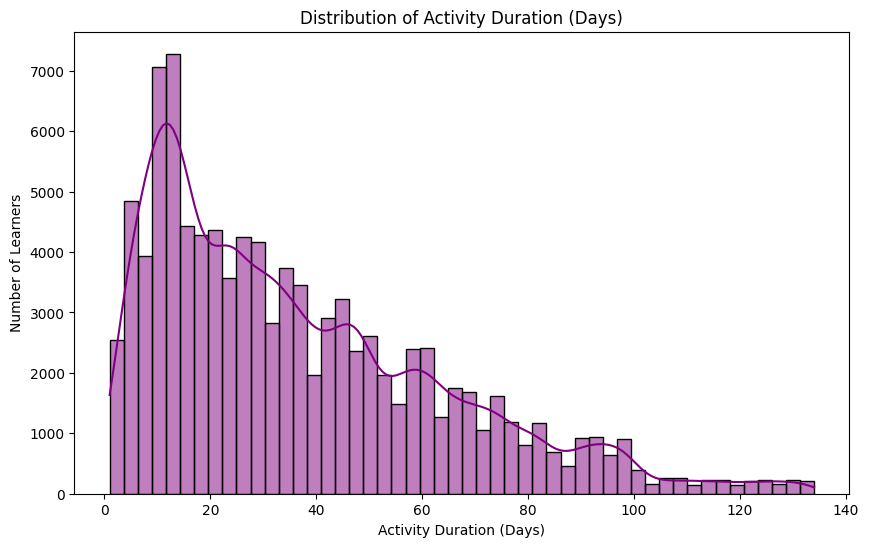

In [24]:
# 8. Time-series Analysis: Activity Duration Distribution
df["activity_duration_days"] = (df["last_activity_date"] - df["enrollment_date"]).dt.days
plt.figure(figsize=(10, 6))
sns.histplot(df["activity_duration_days"], bins=50, kde=True, color='purple')
plt.title("Distribution of Activity Duration (Days)")
plt.xlabel("Activity Duration (Days)")
plt.ylabel("Number of Learners")

Text(0.5, 1.0, 'Digital Literacy Score by Course Completion')

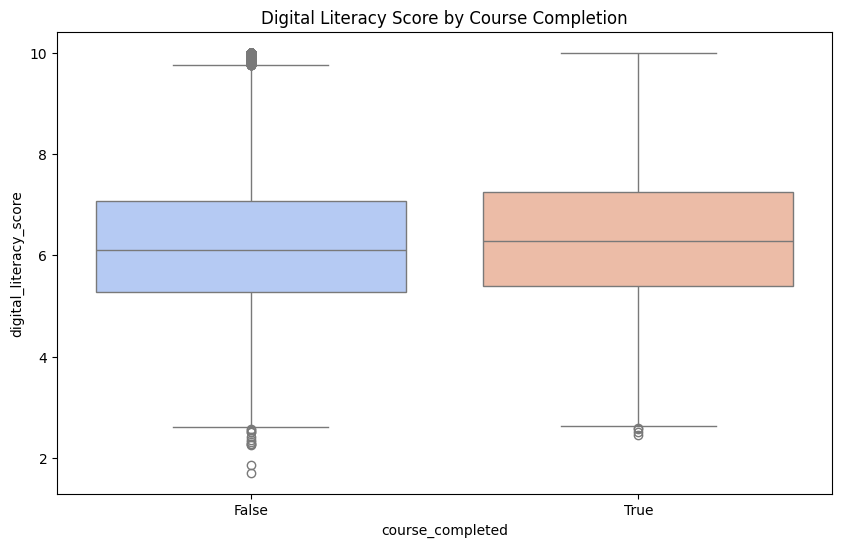

In [25]:
# 9. Imbalanced Classification Impact: Feature Distribution by Course Completion
# Example: digital_literacy_score vs course_completed
plt.figure(figsize=(10, 6))
sns.boxplot(x='course_completed', y='digital_literacy_score', data=df, palette='coolwarm')
plt.title("Digital Literacy Score by Course Completion")

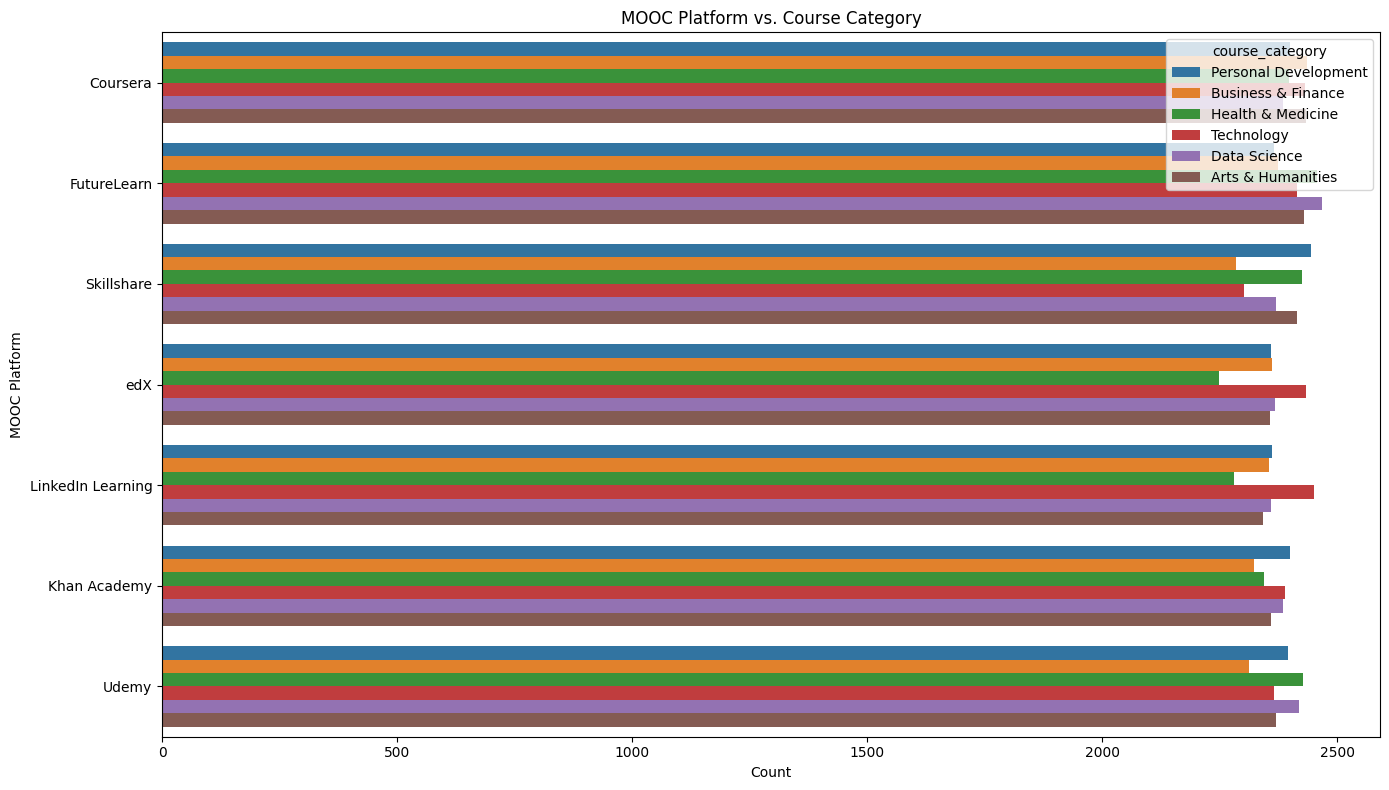

In [26]:
# 10. Multi-domain Data Integration Challenges: Cross-tabulation and Visualization
# Relationship between MOOC Platform and Course Category
plt.figure(figsize=(14, 8))
sns.countplot(y='mooc_platform', hue='course_category', data=df, palette='tab10')
plt.title("MOOC Platform vs. Course Category")
plt.xlabel("Count")
plt.ylabel("MOOC Platform")
plt.tight_layout()

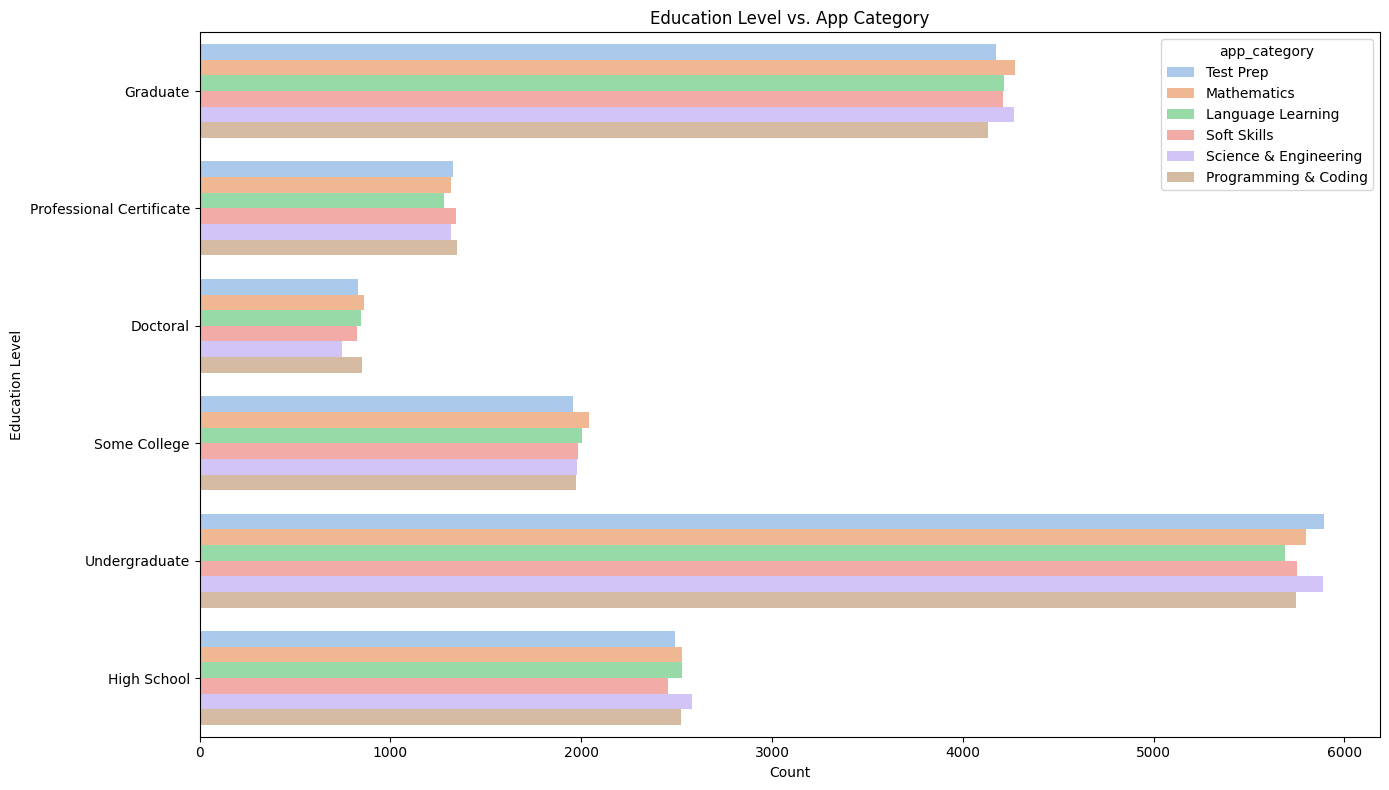

In [27]:
# Relationship between Education Level and App Category
plt.figure(figsize=(14, 8))
sns.countplot(y='education_level', hue='app_category', data=df, palette='pastel')
plt.title("Education Level vs. App Category")
plt.xlabel("Count")
plt.ylabel("Education Level")
plt.tight_layout()

4. Data Preprocessing and Feature Engineering

In [28]:
# 1. Time-Aware Data Splitting (Production-Safe) Train: 2020-2023, Val: 2024, Test: 2025
print("Step 2: Performing Time-Aware Split (Train: 2020-2023, Val: 2024, Test: 2025)")

df['enrollment_year'] = df['enrollment_date'].dt.year
train_df = df[df['enrollment_year'] <= 2023].copy()
val_df = df[df['enrollment_year'] == 2024].copy()
test_df = df[df['enrollment_year'] == 2025].copy()

Step 2: Performing Time-Aware Split (Train: 2020-2023, Val: 2024, Test: 2025)


In [29]:
# 2. Preprocessing and Feature Engineering (Fitted on Train Set Only) ---
# Define categorical and numerical columns
cat_cols = [
    "gender", "education_level", "country", "employment_status", 
    "app_category", "essay_topic_category", "mooc_platform", 
    "course_category", "learning_path_type"
]

num_cols_initial = [
    "age", "prior_online_courses", "digital_literacy_score", "daily_app_minutes", "session_count_weekly",
    "app_completion_rate", "in_app_quiz_score", "gamification_engagement", "skill_pre_score", "skill_post_score",
    "essay_word_count", "essay_grammar_errors", "essay_vocabulary_richness", "essay_coherence_score",
    "human_grader_score", "automated_score", "course_duration_weeks", "video_completion_pct",
    "assignment_submission_rate", "forum_posts", "peer_review_given", "content_difficulty_avg",
    "content_recommendations_followed", "knowledge_gaps_identified", "remediation_modules_completed",
    "time_to_mastery_hours", "learning_efficiency_score", "total_learning_hours", "engagement_consistency"
]

In [30]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
# a) Imputation (Fitted on Train Data)
print("   - Fitting imputer on training data...")
imputer = SimpleImputer(strategy="median")
imputer.fit(train_df[num_cols_initial])


   - Fitting imputer on training data...


SimpleImputer(strategy='median')

In [31]:
# b) Outlier Capping Bounds (Calculated from Train Data)
print("   - Calculating outlier bounds from training data...")
outlier_bounds = {}
outlier_cols_to_cap = [col for col in num_cols_initial if col != 'mastery_score'] # Exclude target

for col in outlier_cols_to_cap:
    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outlier_bounds[col] = {'lower': lower_bound, 'upper': upper_bound}

   - Calculating outlier bounds from training data...


In [32]:
# c) Categorical Encoding (Fitted on Train Data - with 'unknown' handling)
print("   - Fitting label encoders on training data (including 'unknown' category)...")
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    # Fit on unique values from training data, plus 'unknown' to handle unseen categories
    unique_train_categories = train_df[col].astype(str).unique()
    le.fit(np.append(unique_train_categories, 'unknown'))
    encoders[col] = le

   - Fitting label encoders on training data (including 'unknown' category)...


In [33]:
# --- 4. Transformation Function (for consistent application) ---

def transform_data(df, imputer, outlier_bounds, encoders):
    '''Applies all preprocessing steps to a given dataframe.'''
    df_transformed = df.copy()

    # Impute missing values
    df_transformed[num_cols_initial] = imputer.transform(df_transformed[num_cols_initial])

    # Cap outliers
    for col, bounds in outlier_bounds.items():
        df_transformed[col] = df_transformed[col].clip(lower=bounds['lower'], upper=bounds['upper'])
     # Feature Engineering
    df_transformed['activity_duration_days'] = (df_transformed['last_activity_date'] - df_transformed['enrollment_date']).dt.days
    df_transformed['skill_improvement'] = df_transformed['skill_post_score'] - df_transformed['skill_pre_score']
    df_transformed['engagement_score'] = (df_transformed['video_completion_pct'] + df_transformed['assignment_submission_rate'] + df['engagement_consistency'] * 100) / 3
    df_transformed['learning_velocity'] = df_transformed['total_learning_hours'] / (df_transformed['course_duration_weeks'] + 1e-6)
    df_transformed['essay_error_rate'] = df_transformed['essay_grammar_errors'] / (df_transformed['essay_word_count'] + 1e-6)
     # Encode categorical features
    for col, le in encoders.items():
        # Map unseen values to 'unknown' before transforming
        df_transformed[col] = df_transformed[col].astype(str).apply(lambda x: x if x in le.classes_ else 'unknown')
        df_transformed[col] = le.transform(df_transformed[col])

    return df_transformed    


In [34]:
print("Step 4: Applying transformations to train, val, and test sets")
train_processed = transform_data(train_df, imputer, outlier_bounds, encoders)
val_processed = transform_data(val_df, imputer, outlier_bounds, encoders)
test_processed = transform_data(test_df, imputer, outlier_bounds, encoders)

Step 4: Applying transformations to train, val, and test sets


In [35]:
# --- 5. Final Data Preparation for Modeling ---
print("Step 5: Preparing final datasets for classification and regression")

Step 5: Preparing final datasets for classification and regression


In [36]:
# Define final feature columns to use (excluding identifiers, dates, and targets)
features_to_drop = ['learner_id', 'enrollment_date', 'last_activity_date', 'enrollment_year', 'enrollment_month_year', 'course_completed', 'mastery_score']
X_train = train_processed.drop(columns=features_to_drop)
X_val = val_processed.drop(columns=features_to_drop)
X_test = test_processed.drop(columns=features_to_drop)

In [37]:

# Align columns after feature engineering to ensure consistency
final_cols = X_train.columns
X_val = X_val[final_cols]
X_test = X_test[final_cols]



In [38]:
# Classification Targets
y_train_c = train_processed['course_completed'].astype(int)
y_val_c = val_processed['course_completed'].astype(int)
y_test_c = test_processed['course_completed'].astype(int)

In [39]:
# Regression Targets
y_train_r = train_processed['mastery_score']
y_val_r = val_processed['mastery_score']
y_test_r = test_processed['mastery_score']

In [40]:
# --- 6. Scaling (Fitted on Train Data) ---
print("Step 6: Fitting single scaler on training data and transforming all sets")

# Use a single scaler as features are the same for both tasks
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

Step 6: Fitting single scaler on training data and transforming all sets


In [41]:
print(f"\nFinal Scaled Feature Shape (Train): {X_train_scaled.shape}")
print(f"Final Scaled Feature Shape (Validation): {X_val_scaled.shape}")
print(f"Final Scaled Feature Shape (Test): {X_test_scaled.shape}")


Final Scaled Feature Shape (Train): (66632, 43)
Final Scaled Feature Shape (Validation): (16743, 43)
Final Scaled Feature Shape (Test): (16625, 43)


In [42]:
import os
import joblib
os.makedirs("artifacts", exist_ok=True)

In [43]:
joblib.dump(imputer, 'artifacts/imputer.joblib')
joblib.dump(encoders, 'artifacts/label_encoders.joblib')
joblib.dump(scaler, 'artifacts/scaler.joblib')

['artifacts/scaler.joblib']

Model Selection
 (establishing baseline models for classification and regression)

In [44]:

print("\n## 5. Model Building - Classification (MOOC Course Completion)")
print("### a. Using In-Memory Processed Data")

# Since we are in the same notebook, reuse scaled datasets directly
X_train_c_scaled = X_train_scaled
X_val_c_scaled = X_val_scaled
X_test_c_scaled = X_test_scaled

# Targets already defined earlier
# y_train_c, y_val_c, y_test_c


print("Classification Data Ready:")
print(f"X_train_c_scaled shape: {X_train_c_scaled.shape}")
print(f"y_train_c shape: {y_train_c.shape}")
print(f"X_val_c_scaled shape: {X_val_c_scaled.shape}")
print(f"y_val_c shape: {y_val_c.shape}")
print(f"X_test_c_scaled shape: {X_test_c_scaled.shape}")
print(f"y_test_c shape: {y_test_c.shape}")


## 5. Model Building - Classification (MOOC Course Completion)
### a. Using In-Memory Processed Data
Classification Data Ready:
X_train_c_scaled shape: (66632, 43)
y_train_c shape: (66632,)
X_val_c_scaled shape: (16743, 43)
y_val_c shape: (16743,)
X_test_c_scaled shape: (16625, 43)
y_test_c shape: (16625,)


In [45]:
from sklearn.linear_model import LogisticRegression
print("\n### b. Baseline Model: Logistic Regression (with class_weight='balanced')")
print("Training Logistic Regression baseline model...")
log_reg_balanced = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
log_reg_balanced.fit(X_train_c_scaled, y_train_c)

print("Evaluating Logistic Regression on Validation Set...")
y_val_c_pred_logreg = log_reg_balanced.predict(X_val_c_scaled)
y_val_c_proba_logreg = log_reg_balanced.predict_proba(X_val_c_scaled)[:, 1]


### b. Baseline Model: Logistic Regression (with class_weight='balanced')
Training Logistic Regression baseline model...
Evaluating Logistic Regression on Validation Set...


In [46]:
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix
)
from sklearn.metrics import roc_curve


Classification Report (Baseline Logistic Regression - Validation):
              precision    recall  f1-score   support

           0       0.98      0.95      0.97     11523
           1       0.90      0.96      0.93      5220

    accuracy                           0.95     16743
   macro avg       0.94      0.95      0.95     16743
weighted avg       0.96      0.95      0.95     16743

ROC AUC Score (Baseline Logistic Regression - Validation): 0.9932


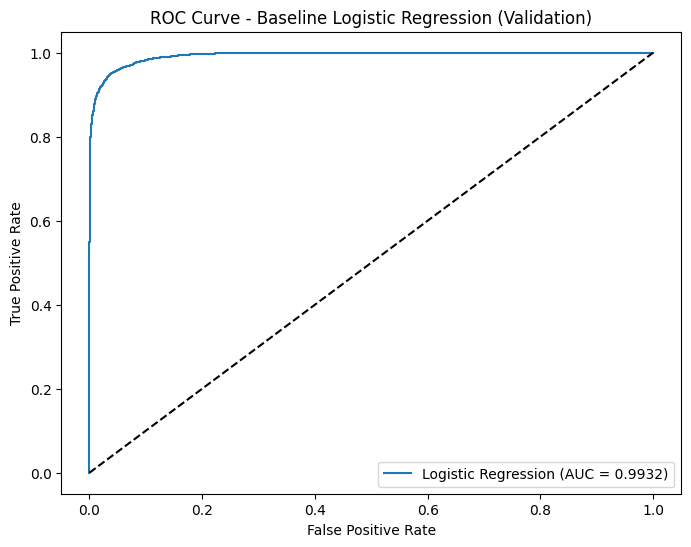

In [47]:
print("\nClassification Report (Baseline Logistic Regression - Validation):")
print(classification_report(y_val_c, y_val_c_pred_logreg))
print(f"ROC AUC Score (Baseline Logistic Regression - Validation): {roc_auc_score(y_val_c, y_val_c_proba_logreg):.4f}")

# Plot ROC Curve for Baseline Logistic Regression
fpr_logreg, tpr_logreg, _ = roc_curve(y_val_c, y_val_c_proba_logreg)
plt.figure(figsize=(8, 6))
plt.plot(fpr_logreg, tpr_logreg, label=f"Logistic Regression (AUC = {roc_auc_score(y_val_c, y_val_c_proba_logreg):.4f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Baseline Logistic Regression (Validation)")
plt.legend()
plt.show()


### c. Advanced Model: RandomForestClassifier (with class_weight='balanced')
Training RandomForestClassifier with class_weight='balanced'...
Evaluating RandomForestClassifier on Validation Set...

Classification Report (RandomForestClassifier - Validation):
              precision    recall  f1-score   support

           0       0.93      0.98      0.95     11523
           1       0.95      0.83      0.88      5220

    accuracy                           0.93     16743
   macro avg       0.94      0.90      0.92     16743
weighted avg       0.93      0.93      0.93     16743

ROC AUC Score (RandomForestClassifier - Validation): 0.9855


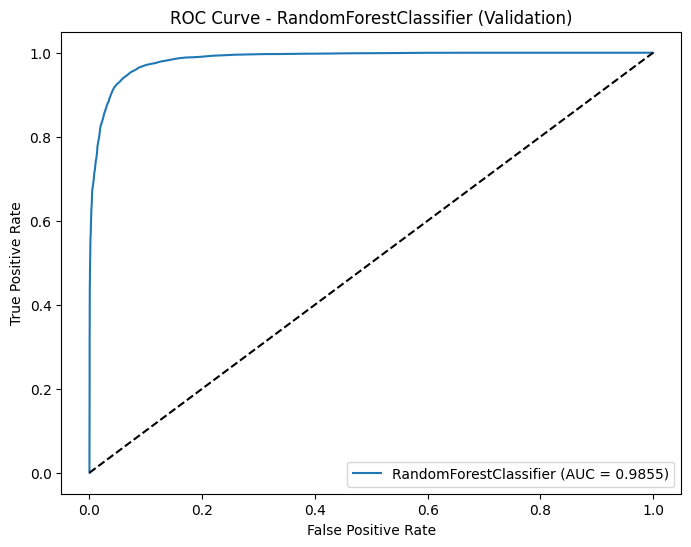

In [48]:
from sklearn.ensemble import RandomForestClassifier
print("\n### c. Advanced Model: RandomForestClassifier (with class_weight=\'balanced\')")
print("Training RandomForestClassifier with class_weight=\'balanced\'...")
rf_classifier_balanced = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_classifier_balanced.fit(X_train_c_scaled, y_train_c)

print("Evaluating RandomForestClassifier on Validation Set...")
y_val_c_pred_rf = rf_classifier_balanced.predict(X_val_c_scaled)
y_val_c_proba_rf = rf_classifier_balanced.predict_proba(X_val_c_scaled)[:, 1]

print("\nClassification Report (RandomForestClassifier - Validation):")
print(classification_report(y_val_c, y_val_c_pred_rf))
print(f"ROC AUC Score (RandomForestClassifier - Validation): {roc_auc_score(y_val_c, y_val_c_proba_rf):.4f}")

# Plot ROC Curve for RandomForestClassifier
fpr_rf, tpr_rf, _ = roc_curve(y_val_c, y_val_c_proba_rf)
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label=f"RandomForestClassifier (AUC = {roc_auc_score(y_val_c, y_val_c_proba_rf):.4f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - RandomForestClassifier (Validation)")
plt.legend()
plt.show()

In [49]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

print("\n### d. Hyperparameter Tuning (RandomizedSearchCV - Faster)")

param_dist = {
    "n_estimators": [50, 100],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5]
}

random_search_c = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1),
    param_dist,
    n_iter=3,           # test only 3 combinations
    cv=2,               # fewer folds = faster
    scoring="roc_auc",
    n_jobs=-1,
    verbose=0,
    random_state=42
)

# Optional speed trick: use subset of training data
sample_n = min(1000, len(X_train_c_scaled))


random_search_c.fit(X_train_c_scaled[:sample_n], y_train_c[:sample_n])

best_rf_classifier = random_search_c.best_estimator_

print("Best Parameters:", random_search_c.best_params_)


### d. Hyperparameter Tuning (RandomizedSearchCV - Faster)
Best Parameters: {'n_estimators': 100, 'min_samples_split': 2, 'max_depth': None}


Evaluating Best Classification Model on Test Set...

Classification Report (Best Model - Test):
              precision    recall  f1-score   support

           0       0.87      0.98      0.92     11525
           1       0.93      0.66      0.78      5100

    accuracy                           0.88     16625
   macro avg       0.90      0.82      0.85     16625
weighted avg       0.89      0.88      0.88     16625

ROC AUC Score (Best Model - Test): 0.9497


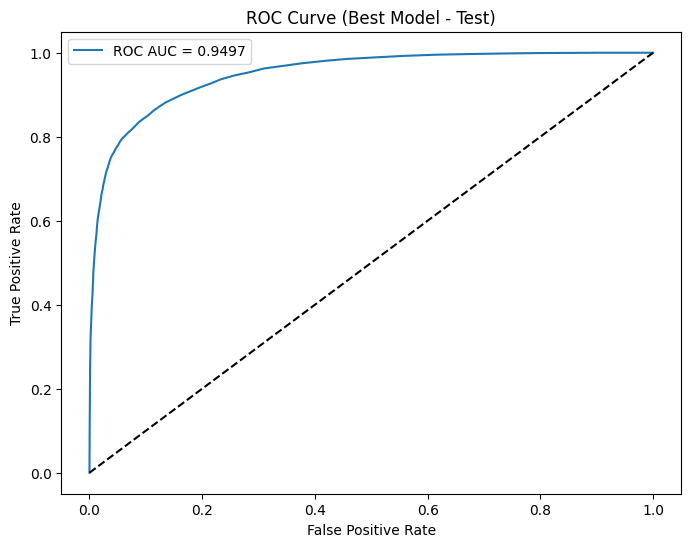

In [50]:
print("Evaluating Best Classification Model on Test Set...")
y_test_c_pred = best_rf_classifier.predict(X_test_c_scaled)
y_test_c_proba = best_rf_classifier.predict_proba(X_test_c_scaled)[:, 1]

print("\nClassification Report (Best Model - Test):")
print(classification_report(y_test_c, y_test_c_pred))
print(f"ROC AUC Score (Best Model - Test): {roc_auc_score(y_test_c, y_test_c_proba):.4f}")

fpr, tpr, _ = roc_curve(y_test_c, y_test_c_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc_score(y_test_c, y_test_c_proba):.4f}")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Best Model - Test)")
plt.legend()

In [51]:
import sys
!{sys.executable} -m pip install shap

You should consider upgrading via the 'c:\Users\siyal\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.



### f.1 Faster SHAP (sampled, stable)


<Figure size 1000x800 with 0 Axes>

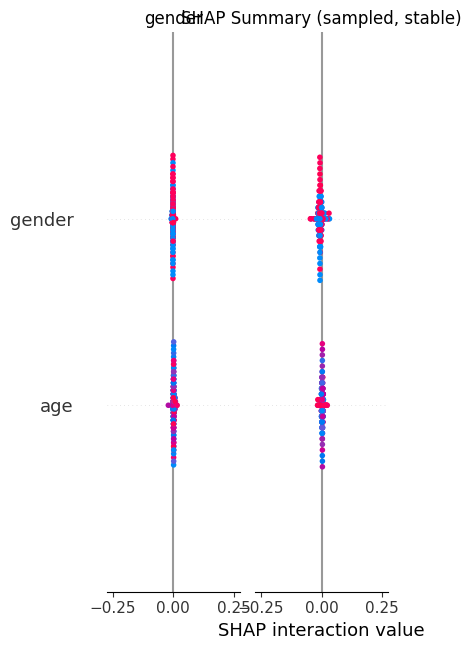

In [52]:
# Faster SHAP (sampled, stable)
import shap
import pandas as pd
import matplotlib.pyplot as plt

print("\n### f.1 Faster SHAP (sampled, stable)")

# Ensure feature names are available
feature_names = list(X_train.columns)

# Convert scaled arrays to DataFrames if needed (for nicer plotting)
X_train_df = pd.DataFrame(X_train_scaled, columns=feature_names)
X_val_df = pd.DataFrame(X_val_c_scaled, columns=feature_names)

# Sample background & validation data
background_array = X_train_scaled[:100]  # first 100 rows as background
X_sample_array = X_val_c_scaled[:200]    # first 200 rows as validation sample
X_sample_df = X_val_df.iloc[:200]        # DataFrame version for plotting labels

# Initialize TreeExplainer
explainer = shap.TreeExplainer(best_rf_classifier)

# Compute SHAP values (disable strict additivity check for safety)
shap_values = explainer(X_sample_array, check_additivity=False)

# Plot SHAP summary
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample_df, feature_names=feature_names, show=False)
plt.title("SHAP Summary (sampled, stable)")
plt.tight_layout()
plt.show()

In [53]:
print("\n### g. Model Report")
print("Classification Model Report: RandomForestClassifier with class_weight=\'balanced\'")
print(f"Best Parameters: {random_search_c.best_params_}")
print(f"Validation ROC AUC: {roc_auc_score(y_val_c, y_val_c_proba_rf):.4f}")
print(f"Test ROC AUC: {roc_auc_score(y_test_c, y_test_c_proba):.4f}")


### g. Model Report
Classification Model Report: RandomForestClassifier with class_weight='balanced'
Best Parameters: {'n_estimators': 100, 'min_samples_split': 2, 'max_depth': None}
Validation ROC AUC: 0.9855
Test ROC AUC: 0.9497


In [54]:
print("### a. Preparing Regression Data (Using In-Memory Variables)")

# Use the already scaled feature sets
X_train_r_scaled = X_train_scaled
X_val_r_scaled = X_val_scaled
X_test_r_scaled = X_test_scaled

### a. Preparing Regression Data (Using In-Memory Variables)


In [55]:
print("Regression Data Ready:")
print(f"X_train_r_scaled shape: {X_train_r_scaled.shape}")
print(f"y_train_r shape: {y_train_r.shape}")
print(f"X_val_r_scaled shape: {X_val_r_scaled.shape}")
print(f"y_val_r shape: {y_val_r.shape}")
print(f"X_test_r_scaled shape: {X_test_r_scaled.shape}")
print(f"y_test_r shape: {y_test_r.shape}")

Regression Data Ready:
X_train_r_scaled shape: (66632, 43)
y_train_r shape: (66632,)
X_val_r_scaled shape: (16743, 43)
y_val_r shape: (16743,)
X_test_r_scaled shape: (16625, 43)
y_test_r shape: (16625,)


In [56]:
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
### b. Baseline Model: Ridge Regression
# print("Training Ridge Regression baseline model...")
ridge_reg = Ridge(random_state=42)
ridge_reg.fit(X_train_r_scaled, y_train_r)

print("Evaluating Ridge Regression on Validation Set...")
y_val_r_pred_base = ridge_reg.predict(X_val_r_scaled)

print("\nRegression Report (Baseline Ridge Regression - Validation):")
print(f"MAE: {mean_absolute_error(y_val_r, y_val_r_pred_base):.4f}")
print(f"MSE: {mean_squared_error(y_val_r, y_val_r_pred_base):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_val_r, y_val_r_pred_base)):.4f}")
print(f"R2 Score: {r2_score(y_val_r, y_val_r_pred_base):.4f}")


Evaluating Ridge Regression on Validation Set...

Regression Report (Baseline Ridge Regression - Validation):
MAE: 4.2829
MSE: 31.4063
RMSE: 5.6041
R2 Score: 0.7768


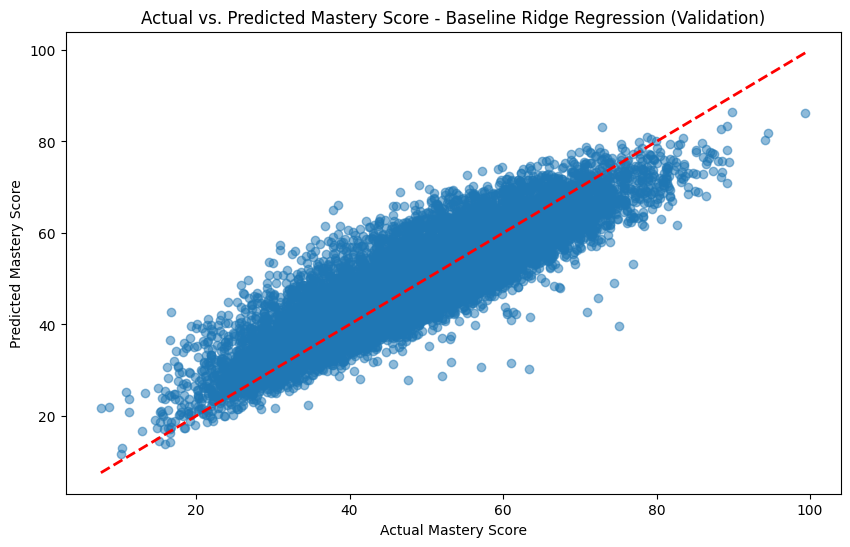

In [57]:
# Plot Actual vs. Predicted for Baseline Ridge Regression
plt.figure(figsize=(10, 6))
plt.scatter(y_val_r, y_val_r_pred_base, alpha=0.5)
plt.plot([y_val_r.min(), y_val_r.max()], [y_val_r.min(), y_val_r.max()], "r--", lw=2)
plt.xlabel("Actual Mastery Score")
plt.ylabel("Predicted Mastery Score")
plt.title("Actual vs. Predicted Mastery Score - Baseline Ridge Regression (Validation)")
plt.show()

In [58]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

param_dist = {
    "n_estimators": [50, 100],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5, 10]
}

# Speed optimizations: fewer iterations, smaller CV, quieter output, and optional subsampling
random_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_dist,
    n_iter=3,      # fewer combinations for faster run
    cv=2,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=0,
    random_state=42,
    return_train_score=False
)

# If the training set is large, fit on a random subset to speed up tuning
sample_n = min(1000, len(X_train_r_scaled))
random_search.fit(X_train_r_scaled[:sample_n], y_train_r[:sample_n])

best_rf_regressor = random_search.best_estimator_

print("Best Parameters:", random_search.best_params_)

Best Parameters: {'n_estimators': 100, 'min_samples_split': 2, 'max_depth': 10}


In [59]:
### e. Model Evaluation (with Residual Analysis)
print("Evaluating Best Regression Model on Validation Set...")
y_val_r_pred = best_rf_regressor.predict(X_val_r_scaled)

print("\nRegression Report (Best Model - Validation):")
print(f"MAE: {mean_absolute_error(y_val_r, y_val_r_pred):.4f}")
print(f"MSE: {mean_squared_error(y_val_r, y_val_r_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_val_r, y_val_r_pred)):.4f}")
print(f"R2 Score: {r2_score(y_val_r, y_val_r_pred):.4f}")


Evaluating Best Regression Model on Validation Set...

Regression Report (Best Model - Validation):
MAE: 2.6050
MSE: 17.4431
RMSE: 4.1765
R2 Score: 0.8760


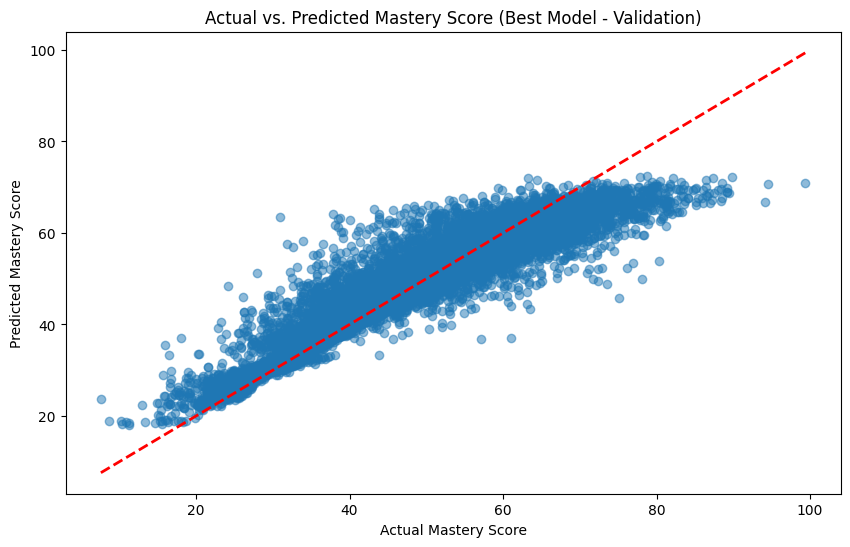

In [60]:
plt.figure(figsize=(10, 6))
plt.scatter(y_val_r, y_val_r_pred, alpha=0.5)
plt.plot([y_val_r.min(), y_val_r.max()], [y_val_r.min(), y_val_r.max()], "r--", lw=2)
plt.xlabel("Actual Mastery Score")
plt.ylabel("Predicted Mastery Score")
plt.title("Actual vs. Predicted Mastery Score (Best Model - Validation)")
plt.show()

In [61]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\siyal\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


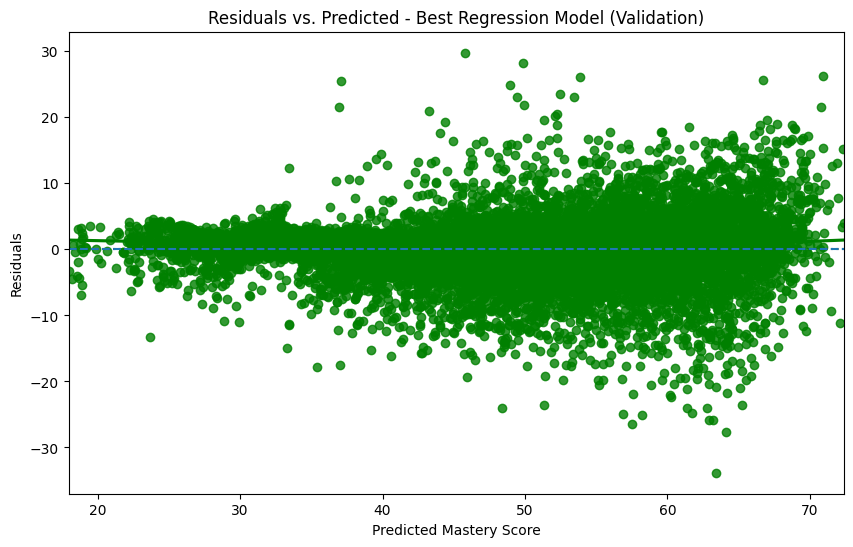

In [62]:
# Residual Plot

plt.figure(figsize=(10, 6))
sns.residplot(x=y_val_r_pred, y=y_val_r - y_val_r_pred, lowess=True, color="g")
plt.axhline(0, linestyle="--")   # reference line
plt.xlabel("Predicted Mastery Score")
plt.ylabel("Residuals")
plt.title("Residuals vs. Predicted - Best Regression Model (Validation)")
plt.show()

In [63]:

print("Evaluating Best Regression Model on Test Set...")
y_test_r_pred = best_rf_regressor.predict(X_test_r_scaled)

print("\nRegression Report (Best Model - Test):")
print(f"MAE: {mean_absolute_error(y_test_r, y_test_r_pred):.4f}")
print(f"MSE: {mean_squared_error(y_test_r, y_test_r_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_r, y_test_r_pred)):.4f}")
print(f"R2 Score: {r2_score(y_test_r, y_test_r_pred):.4f}")

Evaluating Best Regression Model on Test Set...

Regression Report (Best Model - Test):
MAE: 2.6264
MSE: 17.8734
RMSE: 4.2277
R2 Score: 0.8730


Text(0.5, 1.0, 'Actual vs. Predicted Mastery Score (Best Model - Test)')

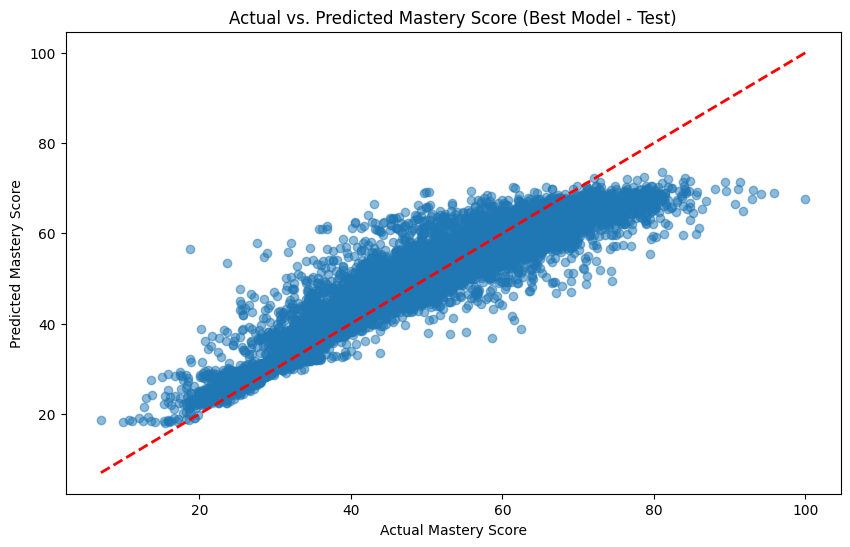

In [64]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test_r, y_test_r_pred, alpha=0.5)
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], "r--", lw=2)
plt.xlabel("Actual Mastery Score")
plt.ylabel("Predicted Mastery Score")
plt.title("Actual vs. Predicted Mastery Score (Best Model - Test)")